<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/Louiza_AKHAM__AI_Workshop_Part_1_to_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Réalisé par Louiza AKHAM


1. Téléchargement local de jeu de données choisi (nous avons choisi la base de données AAPL provenant de la plateforme Padoc).

In [ ]:
# Tout d'abord on va faire appel aux bibliothèques pandas, numpy, matplotlib et seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Ensuite nous allons importer le fichier AAPL depuis notre PC après l'avoir télécharger de la plateforme padoc
df = pd.read_csv('AAPL.csv')
df['Date'] = pd.to_datetime(df['Date'])

# On va créér des caractéristique supplémentaire pour faire l'analyse de nos données
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Price_Range'] = df['High'] - df['Low']
df['Gap'] = df['Open'] - df['Close'].shift(1)

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nSummary Statistics:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

Dataset Shape: (184, 14)
Date Range: 2014-09-29 00:00:00 to 2018-03-29 00:00:00
Missing Values:
Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Daily_Return    1
Month           0
Year            0
Year_Month      0
Day_of_Week     0
Price_Range     0
Gap             1
dtype: int64

Summary Statistics:
             Open        High         Low       Close        Volume
count  184.000000  184.000000  184.000000  184.000000  1.840000e+02
mean   127.040245  129.918098  124.340381  127.352663  1.910168e+08
std     24.314449   24.577906   24.176736   24.356534  8.160281e+07
min     92.389999   93.769997   89.470001   90.519997  3.839850e+07
25%    108.882499  112.362499  106.152502  109.204998  1.273706e+08
50%    118.895000  120.865002  116.870003  119.190002  1.744112e+08
75%    144.935005  147.695000  143.227493  144.704994  2.207755e+08
max    180.289993  183.500000  177.619995  179.979996  5.003630e+08


2. Application de diverses opérations de manipulation des données et de visualisation (types de graphiques) sur le jeu de données à l’aide de NumPy, Pandas, Matplotlib et Seaborn.

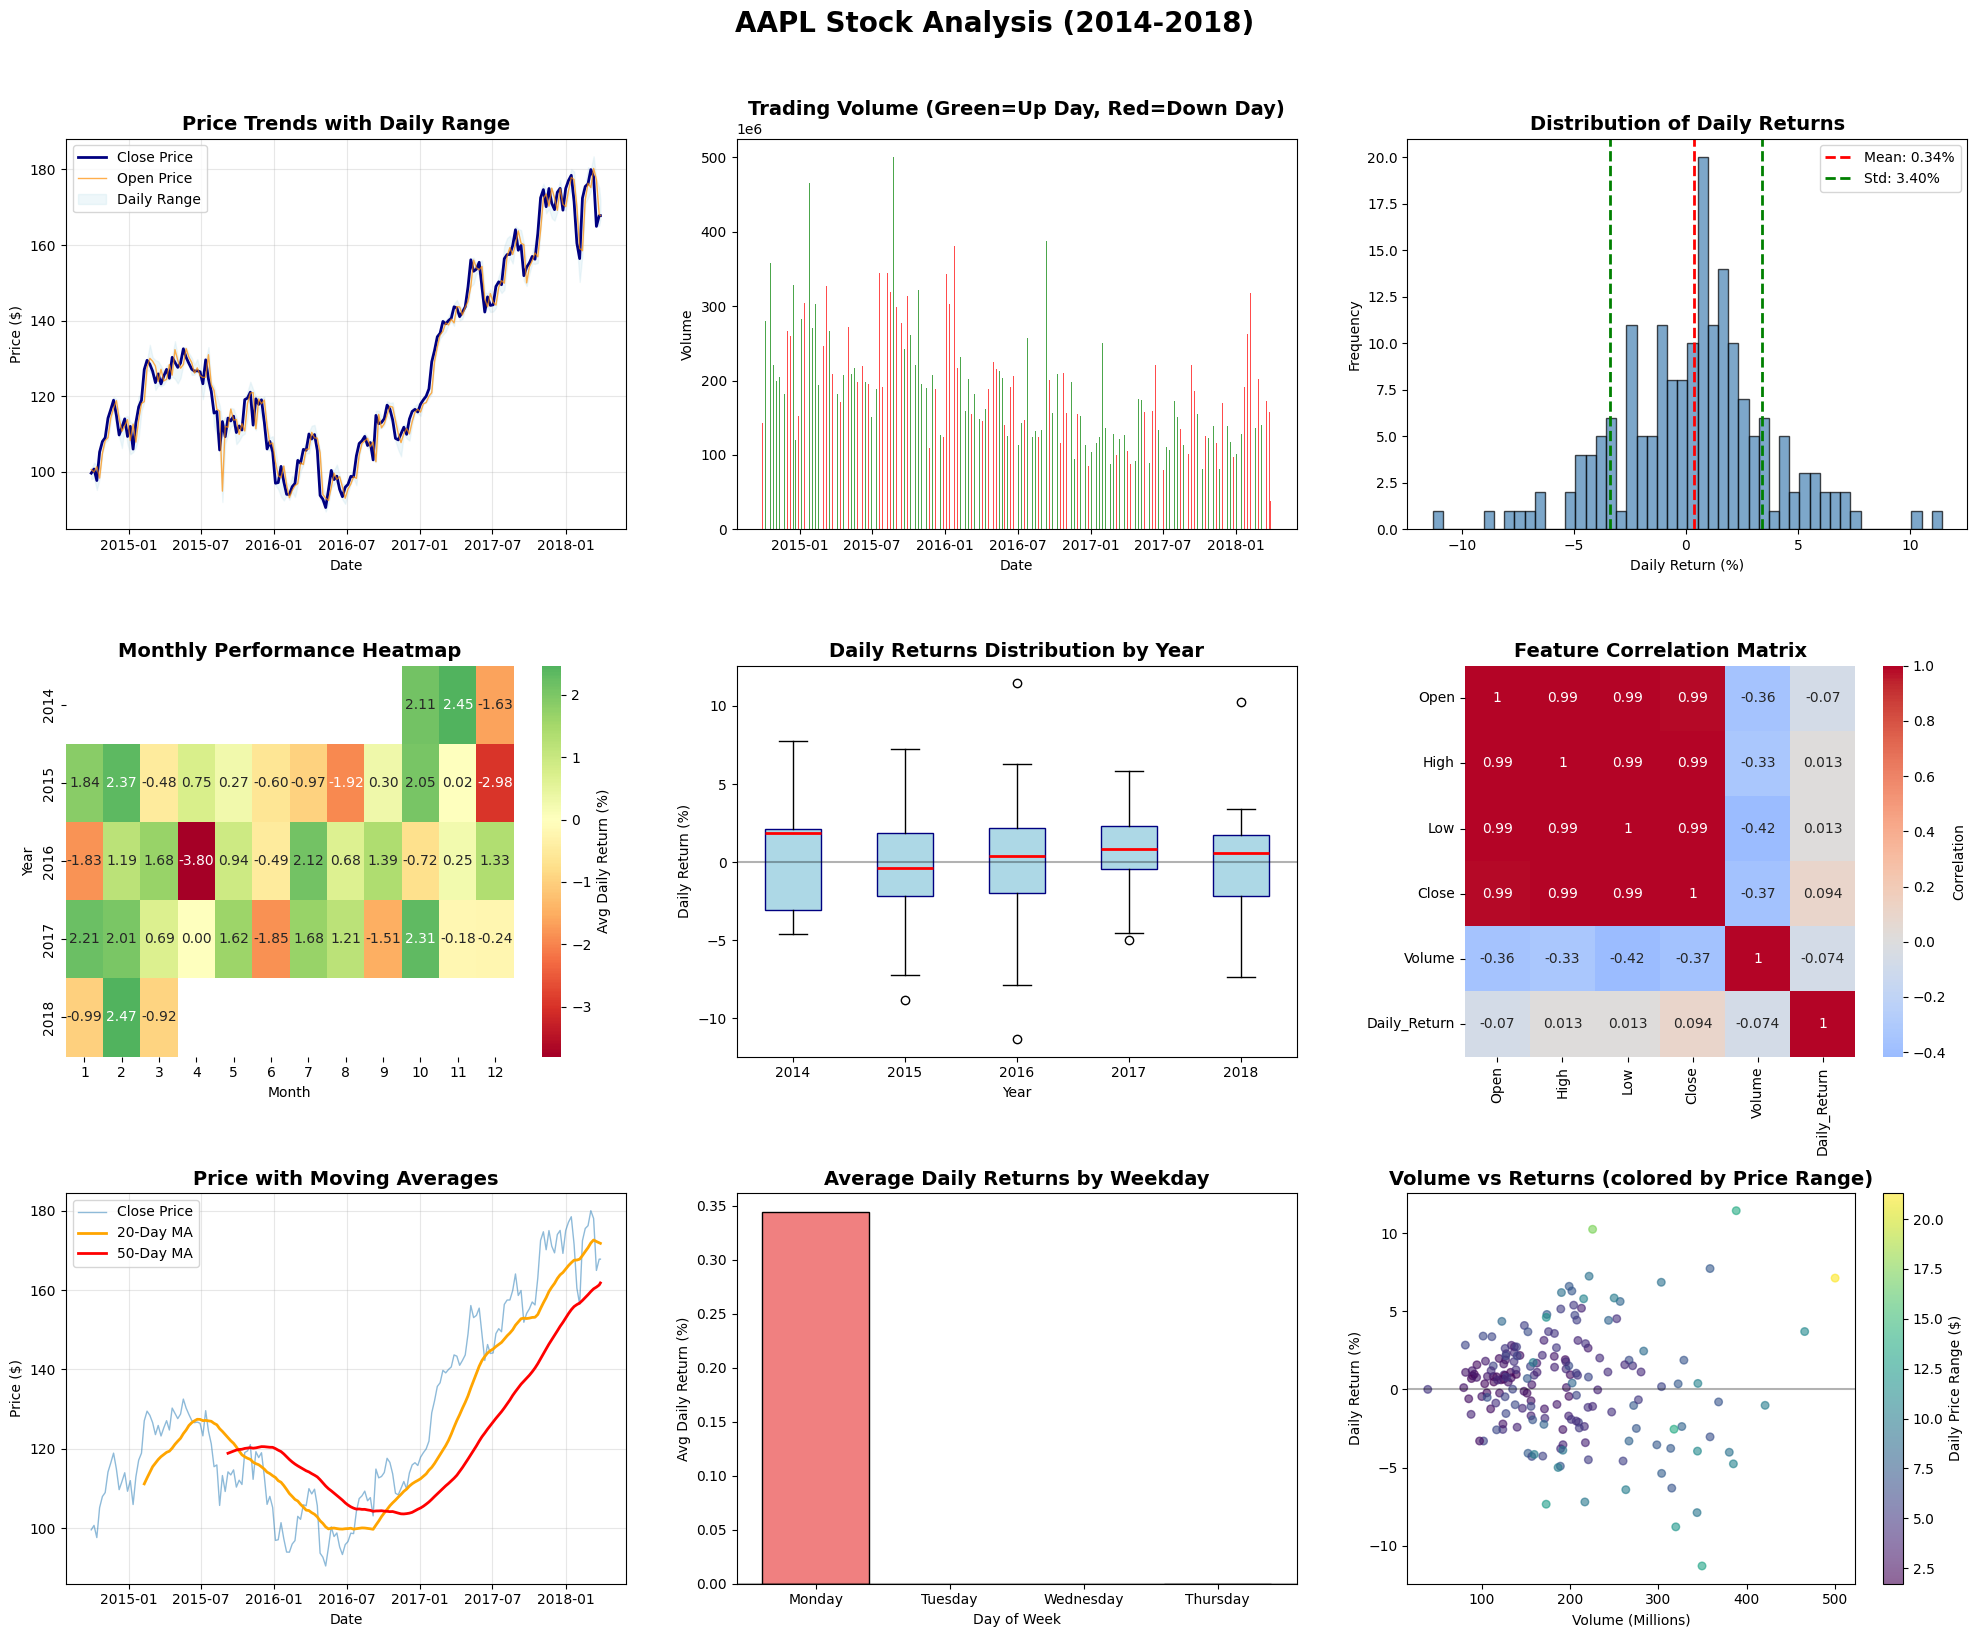

In [ ]:
# Dans cette partie on va mettre en place une figure qui contient plusieurs sous graphiques représentants nos données de base
fig = plt.figure(figsize=(20, 16))
plt.suptitle('AAPL Stock Analysis (2014-2018)', fontsize=20, fontweight='bold', y=1.02)

# 1. Price and Volume Trends (top-left)
ax1 = plt.subplot(3, 3, 1)
ax1.plot(df['Date'], df['Close'], label='Close Price', linewidth=2, color='navy')
ax1.plot(df['Date'], df['Open'], label='Open Price', linewidth=1, alpha=0.7, color='darkorange')
ax1.fill_between(df['Date'], df['Low'], df['High'], alpha=0.2, color='lightblue', label='Daily Range')
ax1.set_title('Price Trends with Daily Range', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Volume Analysis (top-middle)
ax2 = plt.subplot(3, 3, 2)
volume_color = ['green' if close >= open_price else 'red'
                for close, open_price in zip(df['Close'], df['Open'])]
ax2.bar(df['Date'], df['Volume'], color=volume_color, alpha=0.7, width=2)
ax2.set_title('Trading Volume (Green=Up Day, Red=Down Day)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume')
ax2.ticklabel_format(style='sci', axis='y', scilimits=(6,6))

# 3. Daily Returns Distribution (top-right)
ax3 = plt.subplot(3, 3, 3)
returns_data = df['Daily_Return'].dropna()
ax3.hist(returns_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(x=returns_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {returns_data.mean():.2f}%')
ax3.axvline(x=returns_data.std(), color='green', linestyle='--', linewidth=2, label=f'Std: {returns_data.std():.2f}%')
ax3.axvline(x=-returns_data.std(), color='green', linestyle='--', linewidth=2)
ax3.set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
ax3.set_xlabel('Daily Return (%)')
ax3.set_ylabel('Frequency')
ax3.legend()

# 4. Monthly Performance Heatmap (middle-left)
ax4 = plt.subplot(3, 3, 4)
monthly_returns = df.groupby(['Year', 'Month'])['Daily_Return'].mean().unstack()
sns.heatmap(monthly_returns, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Avg Daily Return (%)'}, ax=ax4)
ax4.set_title('Monthly Performance Heatmap', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Year')

# 5. Box Plot by Year (middle)
ax5 = plt.subplot(3, 3, 5)
yearly_data = [df[df['Year'] == year]['Daily_Return'].dropna() for year in sorted(df['Year'].unique())]
bp = ax5.boxplot(yearly_data, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='navy'),
                 medianprops=dict(color='red', linewidth=2))
ax5.set_xticklabels(sorted(df['Year'].unique()))
ax5.set_title('Daily Returns Distribution by Year', fontsize=14, fontweight='bold')
ax5.set_xlabel('Year')
ax5.set_ylabel('Daily Return (%)')
ax5.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 6. Correlation Heatmap (middle-right)
ax6 = plt.subplot(3, 3, 6)
correlation_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, ax=ax6, cbar_kws={'label': 'Correlation'})
ax6.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# 7. Moving Averages (bottom-left)
ax7 = plt.subplot(3, 3, 7)
ax7.plot(df['Date'], df['Close'], label='Close Price', alpha=0.5, linewidth=1)
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
ax7.plot(df['Date'], df['MA_20'], label='20-Day MA', linewidth=2, color='orange')
ax7.plot(df['Date'], df['MA_50'], label='50-Day MA', linewidth=2, color='red')
ax7.set_title('Price with Moving Averages', fontsize=14, fontweight='bold')
ax7.set_xlabel('Date')
ax7.set_ylabel('Price ($)')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Day of Week Analysis (bottom-middle)
ax8 = plt.subplot(3, 3, 8)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_returns = df.groupby('Day_of_Week')['Daily_Return'].mean().reindex(weekday_order)
colors = ['lightcoral', 'gold', 'lightgreen', 'lightblue', 'violet']
ax8.bar(weekday_returns.index, weekday_returns.values, color=colors, edgecolor='black')
ax8.set_title('Average Daily Returns by Weekday', fontsize=14, fontweight='bold')
ax8.set_xlabel('Day of Week')
ax8.set_ylabel('Avg Daily Return (%)')
ax8.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 9. Price vs Volume Scatter (bottom-right)
ax9 = plt.subplot(3, 3, 9)
scatter = ax9.scatter(df['Volume']/1e6, df['Daily_Return'],
                     c=df['Price_Range'], cmap='viridis', alpha=0.6, s=30)
ax9.set_title('Volume vs Returns (colored by Price Range)', fontsize=14, fontweight='bold')
ax9.set_xlabel('Volume (Millions)')
ax9.set_ylabel('Daily Return (%)')
plt.colorbar(scatter, ax=ax9, label='Daily Price Range ($)')
ax9.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('aapl_static_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Pour chaque graphique nous allons faire une interprétataion :

**Price Trends with Daily Range (Tendances des Prix avec Fourchette Journalière):** Visualisation linéaire des prix de clôture et d'ouverture avec une zone ombrée représentant la fourchette quotidienne (High-Low).

**Trading Volume (Volume d'Échanges)**: Diagramme à barres du volume journalier, coloré selon la performance (vert si clôture ≥ ouverture, rouge sinon).

**Distribution of Daily Returns (Distribution des Rendements Journaliers)** : Histogramme montrant la fréquence des variations quotidiennes.

**Monthly Performance Heatmap (Carte de Chaleur Mensuelle) **: Matrice couleur des performances moyennes par mois/année.

**Daily Returns Distribution by Year (Distribution des Rendements par Année)**: Boîtes à moustaches montrant la distribution statistique par année.

**Feature Correlation Matrix (Matrice de Corrélation) **: Carte de chaleur montrant les corrélations entre variables.

**Price with Moving Averages (Prix avec Moyennes Mobiles)** : Prix avec deux moyennes mobiles (20 et 50 jours) pour identifier tendances.

**Average Daily Returns by Weekday (Rendements Moyens par Jour de la Semaine)**: Diagramme en barres comparant la performance selon le jour

**Volume vs Returns (Volume vs Rendements)** : Nuage de points avec couleur représentant l'amplitude journalière.

3.Application de diverses opérations de manipulation des données et de visualisation (types de graphiques) sur le jeu de données à l’aide de Plotly


In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Création du graphique en chandelier interactif
fig1 = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    name='AAPL',
    increasing_line_color='green',
    decreasing_line_color='red'
)])
# L'ajout des moyennes mobiles
fig1.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA_20'],
    name='20-Day MA',
    line=dict(color='orange', width=2)
))

fig1.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA_50'],
    name='50-Day MA',
    line=dict(color='red', width=2)
))

fig1.update_layout(
    title='AAPL Stock Price - Interactive Candlestick Chart',
    yaxis_title='Price ($)',
    xaxis_title='Date',
    template='plotly_white',
    hovermode='x unified',
    height=600,
    showlegend=True
)

fig1.show()

In [ ]:
# Création d'un tableau de bord avec plusieurs graphiques interactifs
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Price & Volume Trends', 'Daily Returns Distribution',
                    'Monthly Returns Heatmap', 'Correlation Matrix'),
    specs=[[{'type': 'scatter'}, {'type': 'histogram'}],
           [{'type': 'heatmap'}, {'type': 'heatmap'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)
# 1. Price and Volume (top-left)
fig2.add_trace(
    go.Scatter(x=df['Date'], y=df['Close'], name='Close Price',
               line=dict(color='navy', width=2)),
    row=1, col=1
)

fig2.add_trace(
    go.Bar(x=df['Date'], y=df['Volume']/1e6, name='Volume (Millions)',
           marker_color='rgba(100, 149, 237, 0.6)',
           yaxis='y2'),
    row=1, col=1
)

# 2. Returns distribution (top-right)
fig2.add_trace(
    go.Histogram(x=df['Daily_Return'].dropna(), nbinsx=50,
                 name='Daily Returns',
                 marker_color='steelblue',
                 opacity=0.7),
    row=1, col=2
)


In [ ]:
# Mettre à jour la mise en page
fig2.update_layout(
    title_text='AAPL Stock - Interactive Dashboard',
    height=800,
    showlegend=True,
    template='plotly_white',
    yaxis=dict(title='Price ($)'),
    yaxis2=dict(title='Volume (Millions)', overlaying='y', side='right'),
    yaxis3=dict(title='Frequency'),
    yaxis4=dict(title='Year'),
    xaxis4=dict(title='Month'),
    yaxis5=dict(title='Features'),
    xaxis5=dict(title='Features')
)

fig2.show()